# Training the Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())

X_train shape: (144652, 80)
X_test shape: (20354, 80)

Training target distribution:
readmitted
0    72326
1    72326
Name: count, dtype: int64


In [2]:
def evaluate_model(name, model, X_test, y_test):
    """
    Evaluates a trained model and returns key metrics.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, 
          target_names=['Not Readmitted', 'Readmitted']))
    
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    print(f"AUC-ROC Score: {auc:.4f}")
    
    return {
        'Model': name,
        'AUC-ROC': round(auc, 4),
        'F1 Score': round(f1, 4),
        'Recall': round(recall, 4),
        'Precision': round(precision, 4)
    }


In [9]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
)
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(
    'Logistic Regression', 
    lr_model, 
    X_test, 
    y_test
)
print("\nLogistic Regression training complete!")

Training Logistic Regression...

Model: Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.89      0.99      0.94     18083
    Readmitted       0.33      0.04      0.07      2271

      accuracy                           0.88     20354
     macro avg       0.61      0.52      0.51     20354
  weighted avg       0.83      0.88      0.84     20354

AUC-ROC Score: 0.5708

Logistic Regression training complete!


In [10]:
print("Training Random Forest...")
print("(This may take a few minutes...)")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1        # Uses all CPU cores
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    'Random Forest',
    rf_model,
    X_test,
    y_test
)
print("\nRandom Forest training complete!")

Training Random Forest...
(This may take a few minutes...)

Model: Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.89      0.99      0.94     18083
    Readmitted       0.36      0.03      0.05      2271

      accuracy                           0.89     20354
     macro avg       0.63      0.51      0.49     20354
  weighted avg       0.83      0.89      0.84     20354

AUC-ROC Score: 0.6336

Random Forest training complete!


In [7]:
print("Training XGBoost...")

# Calculate scale_pos_weight for imbalanced data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(
    'XGBoost',
    xgb_model,
    X_test,
    y_test
)
print("\nXGBoost training complete!")

Training XGBoost...

Model: XGBoost
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     18083
    Readmitted       0.57      0.03      0.06      2271

      accuracy                           0.89     20354
     macro avg       0.73      0.51      0.50     20354
  weighted avg       0.86      0.89      0.84     20354

AUC-ROC Score: 0.6711

XGBoost training complete!



Model Comparison:
                     AUC-ROC  F1 Score  Recall  Precision
Model                                                    
Logistic Regression   0.5708    0.0727  0.0410     0.3252
Random Forest         0.6336    0.0492  0.0264     0.3614
XGBoost               0.6711    0.0553  0.0291     0.5690


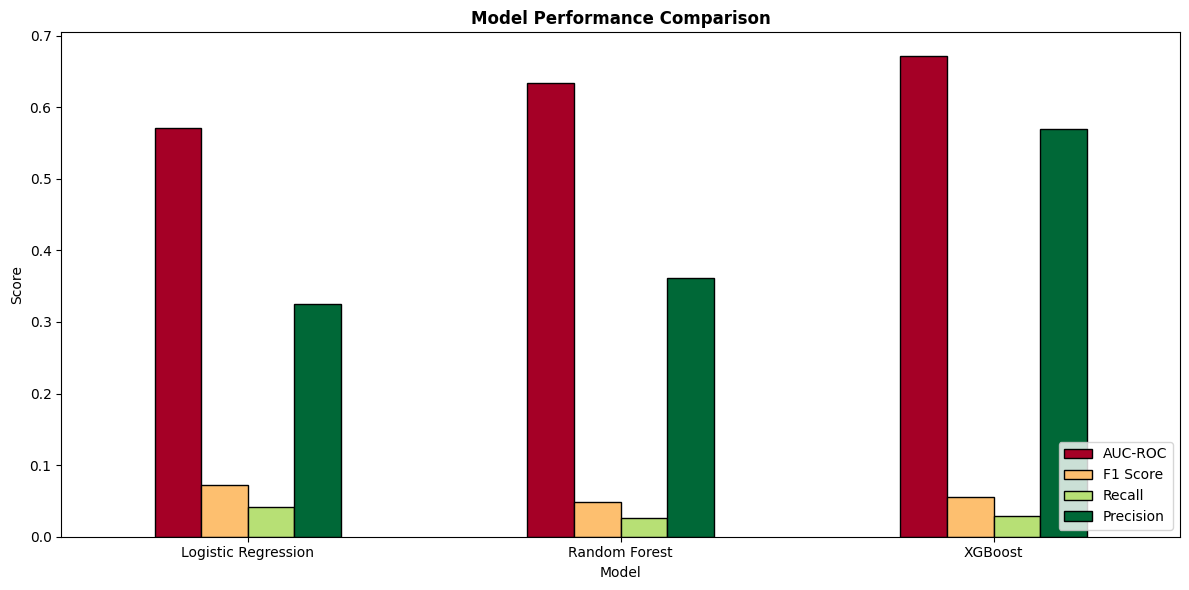

In [11]:
# Create comparison dataframe
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.set_index('Model')

print("\nModel Comparison:")
print(results_df)

# Visualize comparison
results_df.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='RdYlGn',
    edgecolor='black'
)
plt.title('Model Performance Comparison', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
def optimize_threshold(name, model, X_test, y_test):
    """
    Finds the optimal threshold that maximizes Recall
    while keeping Precision above a minimum acceptable level.
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    
    thresholds = np.arange(0.1, 0.5, 0.01)
    results = []
    
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        recall = recall_score(y_test, y_pred, zero_division=0)
        precision = precision_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        results.append({
            'Threshold': round(thresh, 2),
            'Recall': round(recall, 4),
            'Precision': round(precision, 4),
            'F1': round(f1, 4)
        })
    
    results_df = pd.DataFrame(results)
    
    # Find threshold where F1 is maximized
    best_idx = results_df['F1'].idxmax()
    best = results_df.loc[best_idx]
    
    print(f"\n{name} — Best Threshold: {best['Threshold']}")
    print(f"Recall: {best['Recall']}")
    print(f"Precision: {best['Precision']}")
    print(f"F1: {best['F1']}")
    
    return results_df, best['Threshold']

# Run for all three models
lr_thresh_df, lr_best_thresh = optimize_threshold(
    'Logistic Regression', lr_model, X_test, y_test)

rf_thresh_df, rf_best_thresh = optimize_threshold(
    'Random Forest', rf_model, X_test, y_test)

xgb_thresh_df, xgb_best_thresh = optimize_threshold(
    'XGBoost', xgb_model, X_test, y_test)


Logistic Regression — Best Threshold: 0.24
Recall: 0.3672
Precision: 0.1504
F1: 0.2134

Random Forest — Best Threshold: 0.23
Recall: 0.4082
Precision: 0.1825
F1: 0.2522

XGBoost — Best Threshold: 0.16
Recall: 0.4218
Precision: 0.2055
F1: 0.2764


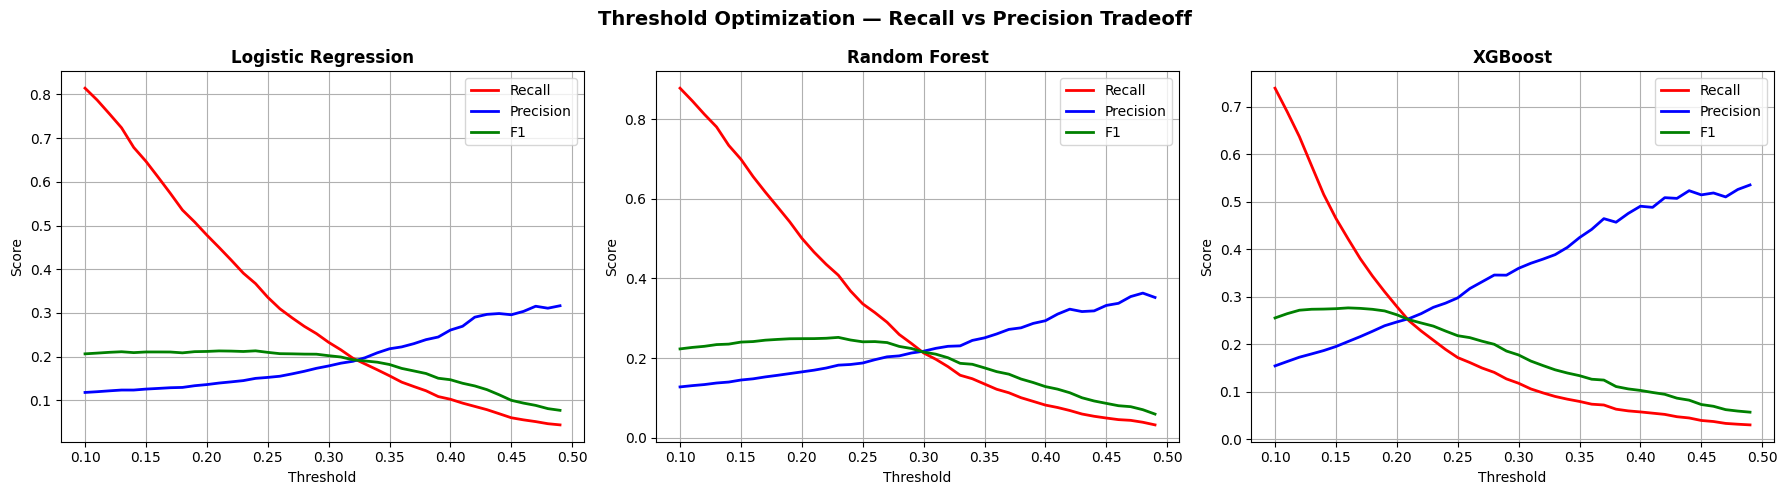

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ('Logistic Regression', lr_thresh_df),
    ('Random Forest', rf_thresh_df),
    ('XGBoost', xgb_thresh_df)
]

for ax, (name, df_thresh) in zip(axes, models_data):
    ax.plot(df_thresh['Threshold'], df_thresh['Recall'], 
            label='Recall', color='red', linewidth=2)
    ax.plot(df_thresh['Threshold'], df_thresh['Precision'], 
            label='Precision', color='blue', linewidth=2)
    ax.plot(df_thresh['Threshold'], df_thresh['F1'], 
            label='F1', color='green', linewidth=2)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True)

plt.suptitle('Threshold Optimization — Recall vs Precision Tradeoff', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/11_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
def evaluate_with_threshold(name, model, X_test, y_test, threshold):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    print(f"\n{'='*50}")
    print(f"{name} at threshold={threshold}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Not Readmitted', 'Readmitted']))
    
    return {
        'Model': name,
        'Threshold': threshold,
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4)
    }

lr_final = evaluate_with_threshold(
    'Logistic Regression', lr_model, X_test, y_test, lr_best_thresh)

rf_final = evaluate_with_threshold(
    'Random Forest', rf_model, X_test, y_test, rf_best_thresh)

xgb_final = evaluate_with_threshold(
    'XGBoost', xgb_model, X_test, y_test, xgb_best_thresh)

# Final comparison
final_df = pd.DataFrame([lr_final, rf_final, xgb_final])
final_df = final_df.set_index('Model')
print("\nFinal Model Comparison After Threshold Optimization:")
print(final_df)


Logistic Regression at threshold=0.24
                precision    recall  f1-score   support

Not Readmitted       0.90      0.74      0.81     18083
    Readmitted       0.15      0.37      0.21      2271

      accuracy                           0.70     20354
     macro avg       0.53      0.55      0.51     20354
  weighted avg       0.82      0.70      0.75     20354


Random Forest at threshold=0.23
                precision    recall  f1-score   support

Not Readmitted       0.91      0.77      0.84     18083
    Readmitted       0.18      0.41      0.25      2271

      accuracy                           0.73     20354
     macro avg       0.55      0.59      0.54     20354
  weighted avg       0.83      0.73      0.77     20354


XGBoost at threshold=0.16
                precision    recall  f1-score   support

Not Readmitted       0.92      0.80      0.85     18083
    Readmitted       0.21      0.42      0.28      2271

      accuracy                           0.75     203

In [15]:
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning...")
print("(This will take several minutes...)")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# RandomizedSearchCV — tries random combinations
# faster than GridSearchCV which tries ALL combinations
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,              # Try 20 random combinations
    scoring='roc_auc',      # Optimize for AUC-ROC
    cv=3,                   # 3-fold cross validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest AUC-ROC (CV): {random_search.best_score_:.4f}")

Starting Hyperparameter Tuning...
(This will take several minutes...)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters Found:
{'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best AUC-ROC (CV): 0.9493


In [16]:
# Train with best parameters
xgb_tuned = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_tuned.fit(X_train, y_train)

# Evaluate on test set first with default threshold
tuned_results = evaluate_model(
    'XGBoost Tuned',
    xgb_tuned,
    X_test,
    y_test
)

print("\nPrevious XGBoost AUC-ROC:", 0.6711)
print("Tuned XGBoost AUC-ROC:", tuned_results['AUC-ROC'])
print("Improvement:", round(tuned_results['AUC-ROC'] - 0.6711, 4))


Model: XGBoost Tuned
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     18083
    Readmitted       0.50      0.01      0.03      2271

      accuracy                           0.89     20354
     macro avg       0.69      0.51      0.48     20354
  weighted avg       0.85      0.89      0.84     20354

AUC-ROC Score: 0.6527

Previous XGBoost AUC-ROC: 0.6711
Tuned XGBoost AUC-ROC: 0.6527
Improvement: -0.0184


In [17]:
# Find best threshold for tuned model
tuned_thresh_df, tuned_best_thresh = optimize_threshold(
    'XGBoost Tuned', xgb_tuned, X_test, y_test)

# Evaluate with optimal threshold
xgb_tuned_final = evaluate_with_threshold(
    'XGBoost Tuned',
    xgb_tuned,
    X_test,
    y_test,
    tuned_best_thresh
)

print("\nFinal Comparison — Before vs After Tuning:")
comparison = pd.DataFrame([xgb_final, xgb_tuned_final])
print(comparison)


XGBoost Tuned — Best Threshold: 0.19
Recall: 0.5302
Precision: 0.174
F1: 0.2621

XGBoost Tuned at threshold=0.19
                precision    recall  f1-score   support

Not Readmitted       0.92      0.68      0.78     18083
    Readmitted       0.17      0.53      0.26      2271

      accuracy                           0.67     20354
     macro avg       0.55      0.61      0.52     20354
  weighted avg       0.84      0.67      0.73     20354


Final Comparison — Before vs After Tuning:
           Model  Threshold  AUC-ROC  F1 Score  Recall  Precision
0        XGBoost       0.16   0.6711    0.2764  0.4218     0.2055
1  XGBoost Tuned       0.19   0.6527    0.2621  0.5302     0.1740


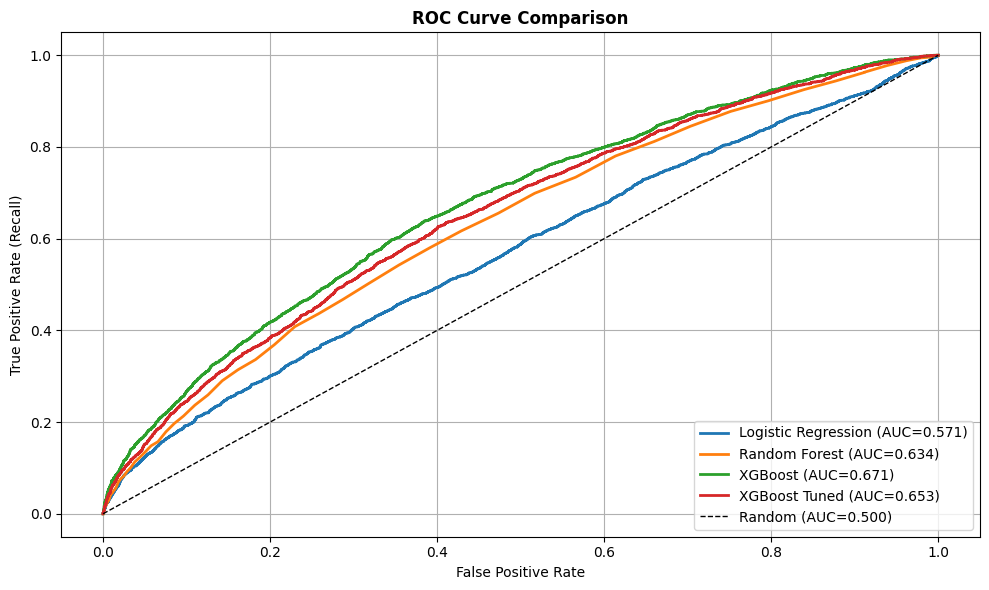

In [18]:
plt.figure(figsize=(10, 6))

models_to_plot = [
    ('Logistic Regression', lr_model),
    ('Random Forest', rf_model),
    ('XGBoost', xgb_model),
    ('XGBoost Tuned', xgb_tuned)
]

for name, model in models_to_plot:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')

plt.title('ROC Curve Comparison', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/12_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

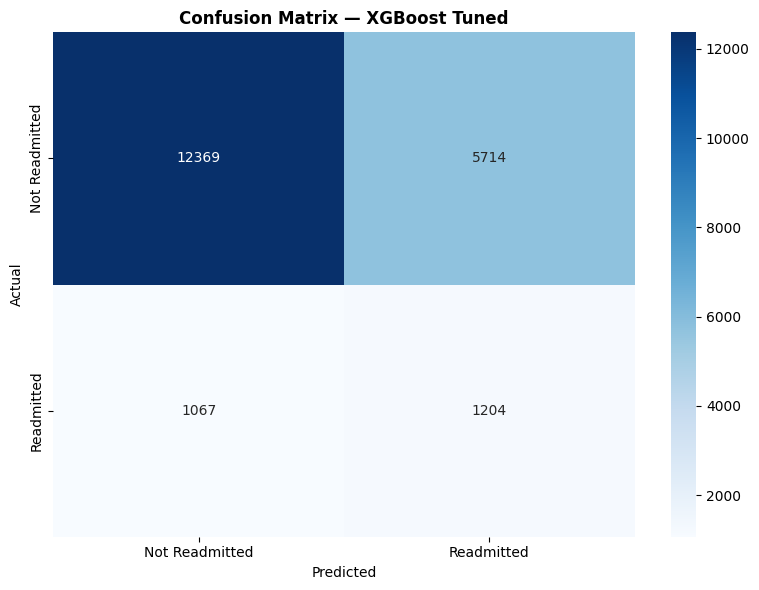


True Negatives  (Correctly said NOT readmitted): 12369
False Positives (Wrongly flagged as readmitted):  5714
False Negatives (Missed actual readmissions):     1067
True Positives  (Correctly caught readmissions):  1204

Of 20354 total patients:
→ Caught 1204 high risk patients correctly
→ Missed 1067 high risk patients
→ False alarmed on 5714 patients


In [19]:
# Using tuned model with optimal threshold
y_prob = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= tuned_best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted']
)
plt.title('Confusion Matrix — XGBoost Tuned', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/13_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correctly said NOT readmitted): {tn}")
print(f"False Positives (Wrongly flagged as readmitted):  {fp}")
print(f"False Negatives (Missed actual readmissions):     {fn}")
print(f"True Positives  (Correctly caught readmissions):  {tp}")
print(f"\nOf {tn+fp+fn+tp} total patients:")
print(f"→ Caught {tp} high risk patients correctly")
print(f"→ Missed {fn} high risk patients")
print(f"→ False alarmed on {fp} patients")

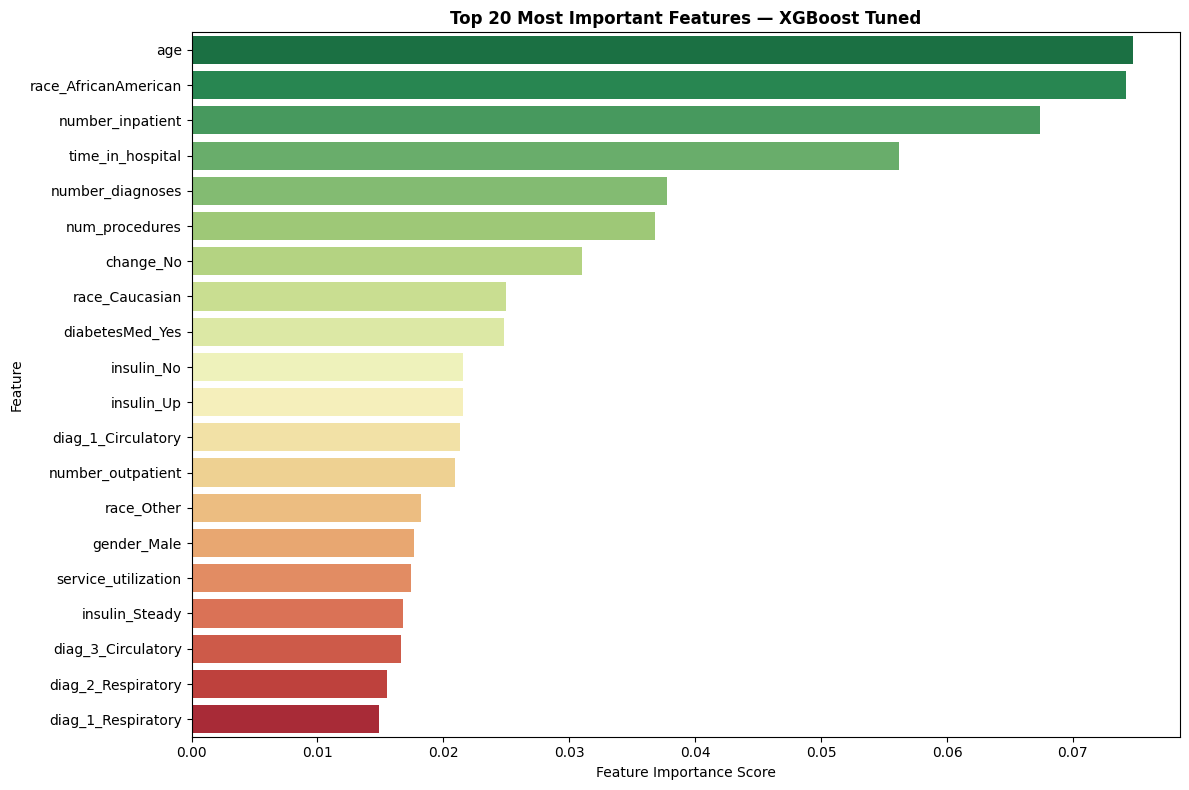


Top 10 Features:
                 Feature  Importance
0                    age    0.074765
13  race_AfricanAmerican    0.074251
10      number_inpatient    0.067369
4       time_in_hospital    0.056194
11      number_diagnoses    0.037745
6         num_procedures    0.036772
78             change_No    0.031005
15        race_Caucasian    0.024995
79       diabetesMed_Yes    0.024799
20            insulin_No    0.021598


In [20]:
# Feature importance of our winning model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importance.head(20),
    x='Importance',
    y='Feature',
    palette='RdYlGn_r'
)
plt.title('Top 20 Most Important Features — XGBoost Tuned', 
          fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../reports/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string())

In [23]:
# Save the winning model and threshold
joblib.dump(xgb_tuned, '../models/xgb_tuned_model.pkl')
joblib.dump(tuned_best_thresh, '../models/best_threshold.pkl')

print("Model saved to models/xgb_tuned_model.pkl")
print("Threshold saved to models/best_threshold.pkl")
print(f"Best threshold: {tuned_best_thresh}")

Model saved to models/xgb_tuned_model.pkl
Threshold saved to models/best_threshold.pkl
Best threshold: 0.19


In [25]:
# Save feature names
import json

feature_names = X_train.columns.tolist()
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Feature names saved!")
print(f"Total features: {len(feature_names)}")

Feature names saved!
Total features: 80
